# Ride Booking Exploratory Analysis

## Task 2: Exploratory Analysis and Visual Summary

This notebook analyzes the cleaned ride booking dataset from Task 1.

The analysis focuses on:
- Trip volume
- Revenue
- Peak booking hours
- City-wise usage
- Driver ratings

The purpose is to identify useful business insights for RapidRide's non-technical staff.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
os.makedirs("../outputs/charts", exist_ok=True)

print("Chart folder is ready!")

Chart folder is ready!


In [3]:
def load_cleaned_data():
    """
    Load the cleaned ride booking dataset from Task 1.
    """

    file_path = "../data/cleaned/cleaned_bookings.csv"

    df = pd.read_csv(file_path)

    # Convert Date column back to datetime for time-based analysis
    df["Date"] = pd.to_datetime(df["Date"])

    return df

In [4]:
df = load_cleaned_data()

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 103024
Columns: 18


In [5]:
df.head()

,Date,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating
0,2024-07-26 14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,Not Applicable,Personal & Car related issue,Not Applicable,Not Applicable,444,Not Applicable,0,NaN,NaN
1,2024-07-25 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,Not Applicable,Not Applicable,No,Not Applicable,158,Cash,13,4.1,4.0
2,2024-07-30 19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,Not Applicable,Not Applicable,No,Not Applicable,386,UPI,40,4.2,4.8
3,2024-07-22 03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,Not Applicable,Not Applicable,Not Applicable,384,Not Applicable,0,NaN,NaN
4,2024-07-02 09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,Not Applicable,Not Applicable,No,Not Applicable,822,Credit Card,45,4.0,3.0


In [6]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Date', 'Booking_ID', 'Booking_Status', 'Customer_ID', 'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT', 'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver', 'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value', 'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[ns]
 1   Booking_ID                  103024 non-null  object        
 2   Booking_Status              103024 non-null  object        
 3   Customer_ID                 103024 non-null  object        
 4   Vehicle_Type                103024 non-null  object        
 5   Pickup_Location             103024 non-null  object        
 6   Drop_Location               103024 non-null  object        
 7   V_TAT                       63967 non-null   float64       
 8   C_TAT                       63967 non-null   float64       
 9   Canceled_Rides_by_Customer  103024 non-null  object        
 10  Canceled_Rides_by_Driver    103024 non-null  object        
 11  Incomplete_Rides            103024 non-

In [8]:
booking_status = df["Booking_Status"].value_counts()

print(booking_status)

Booking_Status
Success                 63967
Canceled by Driver      18434
Canceled by Customer    10499
Driver Not Found        10124
Name: count, dtype: int64


In [9]:
successful_rides = df[df["Booking_Status"] == "Success"].copy()

print("Successful rides:", len(successful_rides))

Successful rides: 63967


In [10]:
df["Hour"] = df["Date"].dt.hour

print(df[["Date", "Hour"]].head())

                 Date  Hour
0 2024-07-26 14:00:00    14
1 2024-07-25 22:20:00    22
2 2024-07-30 19:59:00    19
3 2024-07-22 03:15:00     3
4 2024-07-02 09:02:00     9


In [11]:
trips_by_hour = df.groupby("Hour").size()

print(trips_by_hour)

Hour
0     4318
1     4329
2     4305
3     4201
4     4263
5     4264
6     4271
7     4304
8     4374
9     4347
10    4334
11    4272
12    4408
13    4285
14    4232
15    4376
16    4261
17    4353
18    4176
19    4271
20    4228
21    4343
22    4283
23    4226
dtype: int64


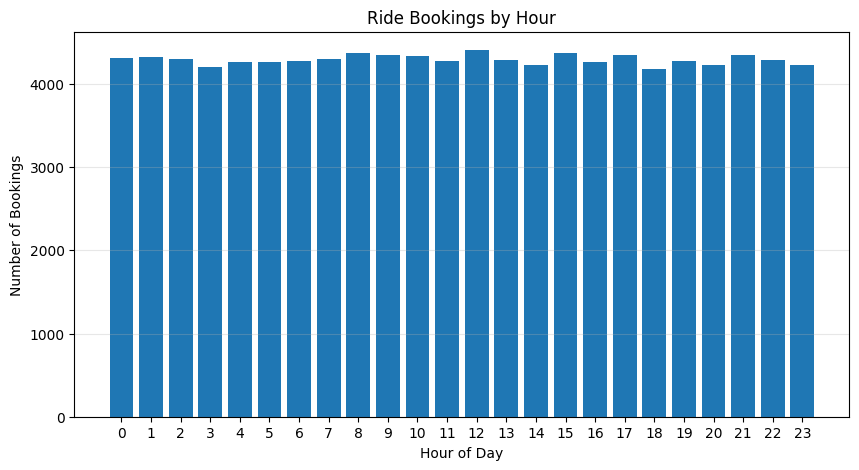

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(trips_by_hour.index, trips_by_hour.values)

plt.title("Ride Bookings by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Bookings")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/charts/trips_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Peak Booking Hours

The hourly booking analysis shows how ride demand changes throughout the day. 
The busiest hours represent periods of higher customer demand, while lower-volume 
hours indicate periods of relatively lower demand. RapidRide can use this 
information to plan driver availability and allocate vehicles according to 
customer demand.